In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json

## Facilities

In [2]:
# facilities
facilities = pd.read_csv('data/Posti Facilities.csv')


In [3]:
def get_coord(coord_dict, key):
    # Handle NaN / None
    if pd.isna(coord_dict):
        return None
    
    # If it's a string, parse it
    if isinstance(coord_dict, str):
        coord_dict = json.loads(coord_dict)
    
    # If it's not a dict after this, return None
    if not isinstance(coord_dict, dict):
        return None
    
    return coord_dict.get(key)

In [4]:
# get values
facilities['longitude'] = facilities['selected_coordinates'].apply(lambda x: get_coord(x, 'longitude'))
facilities['latitude'] = facilities['selected_coordinates'].apply(lambda x: get_coord(x, 'latitude'))

In [5]:
facilities.head()

,location_id_gln,postal_code,address,town,yhdistetty_osoitetieto,maa,selected_coordinates,longitude,latitude
0,6438588004044,66140,Viasvägen 99,ÖVERMALAX,"Viasvägen 99, 66140 ÖVERMALAX",Finland,"{""longitude"":21.631969434124564,""latitude"":62....",21.631969,62.918986
1,6438588003535,44150,Teollisuuskatu 3,ÄÄNEKOSKI,"Teollisuuskatu 3, 44150 ÄÄNEKOSKI",Finland,"{""longitude"":25.70877441062746,""latitude"":62.6...",25.708774,62.605671
2,6438588003528,63700,Ostolantie 10,ÄHTÄRI,"Ostolantie 10, 63700 ÄHTÄRI",Finland,"{""longitude"":24.07181706737183,""latitude"":62.5...",24.071817,62.549903
3,6438588003504,84100,Alpuumintie 6,YLIVIESKA,"Alpuumintie 6, 84100 YLIVIESKA",Finland,"{""longitude"":24.55395961235218,""latitude"":64.0...",24.553960,64.088459
4,6438588003511,84100,Ruutihaantie 12,YLIVIESKA,"Ruutihaantie 12, 84100 YLIVIESKA",Finland,"{""longitude"":24.55548262995899,""latitude"":64.0...",24.555483,64.065630


In [6]:
facilities = facilities.dropna()

In [7]:
facilities['placename'] = facilities['town'].str.capitalize()

In [8]:
sorted(facilities.placename.unique())

['Akaa',
 'Alajärvi',
 'Alavus',
 'Anttola',
 'Aura',
 'Eno',
 'Enontekiö',
 'Espoo',
 'Espoo 63',
 'Eura',
 'Evijärvi',
 'Forssa',
 'Haapajärvi',
 'Haapavesi',
 'Hailuoto',
 'Hamina',
 'Hammaslahti',
 'Hankasalmi',
 'Hanko',
 'Harjavalta',
 'Hartola',
 'Haukipudas',
 'Heinola',
 'Heinävesi',
 'Helsinki',
 'Hollola',
 'Houtskär',
 'Huittinen',
 'Hyrynsalmi',
 'Hyvinkää',
 'Hämeenlinna',
 'Ii',
 'Iisalmi',
 'Ilmajoki',
 'Ilomantsi',
 'Imatra',
 'Iniö',
 'Isojoki',
 'Isokyrö',
 'Ivalo',
 'Jalasjärvi',
 'Joensuu',
 'Jurva',
 'Juuka',
 'Juva',
 'Jyväskylä',
 'Jämsä',
 'Järvenpää',
 'Kaarina',
 'Kaavi',
 'Kajaani',
 'Kalajoki',
 'Kangasala',
 'Kangasniemi',
 'Kankaanpää',
 'Kannus',
 'Karjaa',
 'Karkkila',
 'Karstula',
 'Kauhajoki as',
 'Kauhava',
 'Kausala',
 'Kaustinen',
 'Kemi',
 'Kemijärvi',
 'Keminmaa',
 'Kempele',
 'Kerava',
 'Keuruu',
 'Kirkkonummi',
 'Kitee',
 'Kittilä',
 'Kivijärvi',
 'Kokemäki',
 'Kokkola',
 'Kolari',
 'Konnevesi',
 'Kortesjärvi',
 'Kotka',
 'Kouvola',
 'Kuhmo',
 

In [9]:
geofacilities = gpd.GeoDataFrame(
                        facilities,
                        geometry=gpd.points_from_xy(facilities['longitude'], facilities['latitude']),
                        crs="EPSG:4326"
                    )

In [10]:
geofacilities[['postal_code', 'address', 'town', 'placename', 'longitude', 'latitude']].to_csv('output/posti_facilities_locations.csv', index=False)

(20.8901612878295, 31.410106221570857, 59.3224736781347, 70.41195203713119)

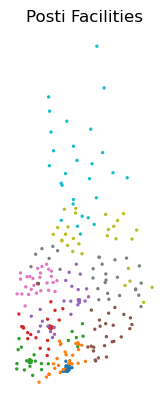

In [11]:
ax = geofacilities.plot(column = 'postal_code', categorical=True, markersize=2)

ax.set_title('Posti Facilities')
ax.axis('off')

## Vehicles

In [12]:
vehicles = pd.read_csv('data/Posti Vehicles.csv', encoding="latin1")

In [13]:
vehicles.head(2)

,Rek,Toimipiste,Tyyppi,Runkonumero,Merkki,Malli,Moottoriteho(kW),Euro-luokitus,Akku(kWh),Käyttövoima,Vuosimalli
0,YJC-976,90100017 eCD CDS Kajaani 9010,Kuorma-auto,ZCFA71EJ302658481,NaN,NaN,NaN,Euro 6,NaN,Diesel,NaN
1,BXT-755,41202400 PS P D BD Kirkkonummi,Pakettiauto,VF7VFAHHWKZ046138,Citroen,Jumpy XL vm.2019,NaN,Euro 6,NaN,Diesel,2019.0


In [14]:
vehicles.tail(2)

,Rek,Toimipiste,Tyyppi,Runkonumero,Merkki,Malli,Moottoriteho(kW),Euro-luokitus,Akku(kWh),Käyttövoima,Vuosimalli
2800,GPU-463,90100035 eCD CDS Ylivieska 9010,Kuorma-auto,YV2VCA0A3RZ157838,Volvo,FE CNG kaasu vm 2024,NaN,NaN,NaN,Kaasu,2024.0
2801,FRI-916,Operations HQ KALUSTOHALLINTA,Kuorma-auto,YV2RTY0C8PA325058,Volvo,NaN,NaN,Euro 6,NaN,Diesel,NaN


In [15]:
vehicles.shape

(2802, 11)

In [16]:
vehicles.Toimipiste.nunique()

197

In [17]:
vehicles['Käyttövoima'].value_counts()

Käyttövoima
Diesel    2056
Sähkö      702
Kaasu       44
Name: count, dtype: int64

In [18]:
vehicles_count = vehicles['Toimipiste'].value_counts().reset_index()
vehicles_count.columns = ['Toimipiste', 'vehicle_count']
print(vehicles_count)

                                            Toimipiste  vehicle_count
0             90100044 eCD CDS Helsinki POK kevyt 9010             55
1                          43620320 PS P D BD TURKU 32             54
2                            41601300 PS P D BD VANTAA             53
3                             44537100 PS P D BD NOKIA             46
4             46560100 PS P D BD Seinäjoki perusjakelu             42
..                                                 ...            ...
192                                               Oulu              1
193  90100011 eCD CDS Turun seudun raskas kotijak 9010              1
194                         90100072 eCD CDS Salo 9010              1
195      90100059 eCD CDS Turun seudun kotijakelu 9010              1
196                      Operations HQ KALUSTOHALLINTA              1

[197 rows x 2 columns]


In [19]:
import re

def extract_place(toimipiste: str) -> str | None:
    if not isinstance(toimipiste, str):
        return None
    tokens = toimipiste.strip().split()
    for tok in reversed(tokens):
        if (not re.fullmatch(r'\d+', tok)
            and len(tok) > 2
            and not re.search(r'\d', tok)
            and re.fullmatch(r'[a-zA-ZäöåÄÖÅ]{3,}', tok)):
            return tok.capitalize()
    return None

vehicles['placename'] = vehicles['Toimipiste'].apply(extract_place)

In [20]:
vehicles.placename.value_counts().reset_index().head(10)

,placename,count
0,Kevyt,230
1,Perusjakelu,95
2,Raskas,92
3,Oulu,88
4,Turku,63
5,Vantaa,53
6,Nokia,46
7,Jyväskylä,41
8,Kajaani,41
9,Kouvola,41


In [21]:
vehicles_available = (
    vehicles
    .groupby('placename')['Käyttövoima']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={'Diesel': 'Diesel', 'Sähkö': 'Electric', 'Kaasu': 'Gas'})
    [['Diesel', 'Electric', 'Gas']]
    .reset_index()
)
vehicles_available.columns.name = None

vehicles_available['Total'] = vehicles_available[['Diesel', 'Electric', 'Gas']].sum(axis=1)



In [22]:
vehicles_available.head()

,placename,Diesel,Electric,Gas,Total
0,Admin,30,0,0,30
1,Alajärvi,18,0,0,18
2,Alavus,25,0,0,25
3,Aura,19,0,0,19
4,Espoo,11,11,0,22


### Merge facility and vehicles

In [23]:
len(facilities)

281

In [24]:
len(vehicles_available)

148

In [25]:
merged = facilities.merge(vehicles_available, on='placename', how='left')

In [26]:
merged_selection = merged[['postal_code', 'placename', 'longitude', 'latitude', 'Diesel', 'Electric', 'Gas', 'Total']].fillna(0)

merged_selection

,postal_code,placename,longitude,latitude,Diesel,Electric,Gas,Total
0,66140,Övermalax,21.631969,62.918986,0.0,0.0,0.0,0.0
1,44150,Äänekoski,25.708774,62.605671,5.0,6.0,0.0,11.0
2,63700,Ähtäri,24.071817,62.549903,8.0,0.0,0.0,8.0
3,84100,Ylivieska,24.553960,64.088459,14.0,9.0,2.0,25.0
4,84100,Ylivieska,24.555483,64.065630,14.0,9.0,2.0,25.0
...,...,...,...,...,...,...,...,...
276,21380,Aura,22.589847,60.648670,19.0,0.0,0.0,19.0
277,52100,Anttola,27.649959,61.582330,0.0,0.0,0.0,0.0
278,63300,Alavus,23.619711,62.585742,25.0,0.0,0.0,25.0
279,62900,Alajärvi,23.816088,63.001861,18.0,0.0,0.0,18.0


In [27]:
merged_selection.to_csv('output/facilities_vehicles_available.csv', index=False)

In [28]:
rovaniemi_facilities = merged_selection.loc[merged_selection.placename == 'Rovaniemi']

rovaniemi_facilities

,postal_code,placename,longitude,latitude,Diesel,Electric,Gas,Total
77,96320,Rovaniemi,25.620261,66.479989,28.0,5.0,4.0,37.0


## Posti Volume

In [30]:
volume = pd.read_csv('data/Posti Volume Index 2025.csv')

In [31]:
volume

,date,day_of_week,week_number,month,year,volume_index
0,01/01/2025,Wednesday,1,1,2025,1433
1,02/01/2025,Thursday,1,1,2025,1575
2,03/01/2025,Friday,1,1,2025,1483
3,04/01/2025,Saturday,1,1,2025,1138
4,05/01/2025,Sunday,1,1,2025,1111
...,...,...,...,...,...,...
360,27/12/2025,Saturday,52,12,2025,983
361,28/12/2025,Sunday,52,12,2025,946
362,29/12/2025,Monday,1,12,2025,1725
363,30/12/2025,Tuesday,1,12,2025,1358


In [32]:
volume['volume_norm'] = volume['volume_index']/volume.volume_index.max()

In [33]:
volume.to_csv('output/volume_demand.csv', index=False)

In [34]:
volume.loc[volume.volume_norm==volume.volume_norm.max()]

,date,day_of_week,week_number,month,year,volume_index,volume_norm
5,06/01/2025,Monday,2,1,2025,2098,1.0


In [35]:
volume.loc[volume.volume_norm==volume.volume_norm.min()]

,date,day_of_week,week_number,month,year,volume_index,volume_norm
179,29/06/2025,Sunday,26,6,2025,493,0.234986


In [36]:
volume['date'] = pd.to_datetime(volume['date'], dayfirst=True)

volume = volume.sort_values('date')

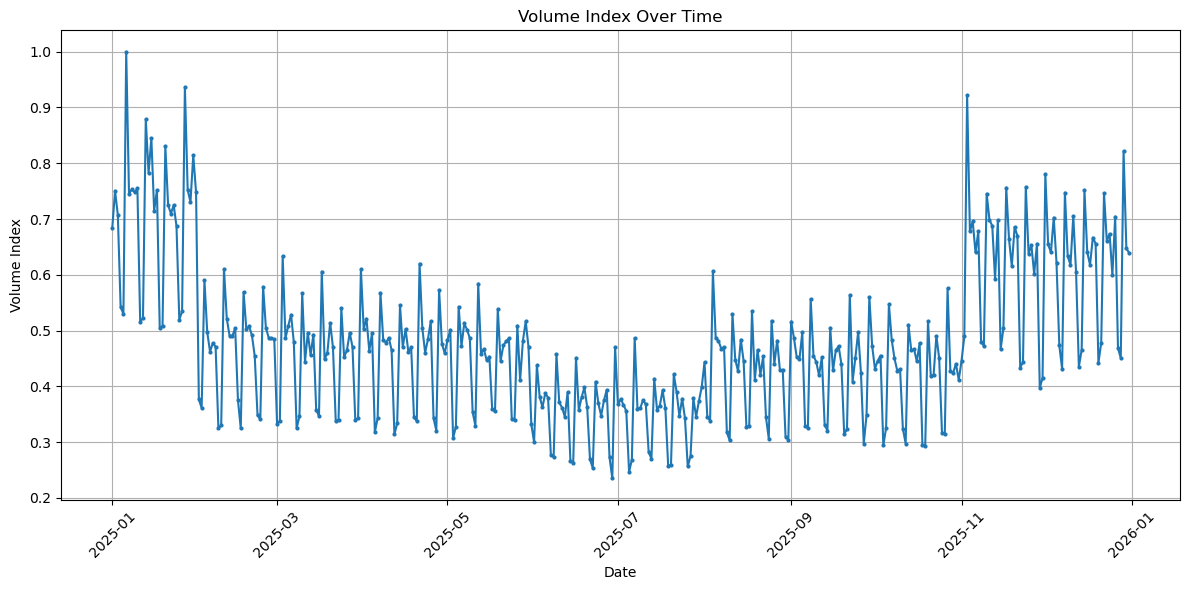

In [37]:
plt.figure(figsize=(12,6))
plt.plot(volume['date'], volume['volume_norm'], marker='o', markersize=2)
plt.title('Volume Index Over Time')
plt.xlabel('Date')
plt.ylabel('Volume Index')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

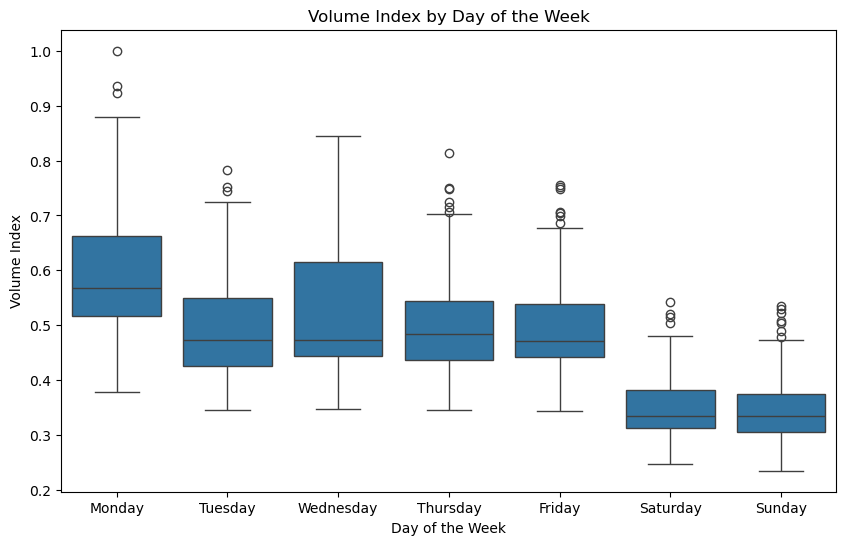

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Boxplot of volume_index per day_of_week
sns.boxplot(x='day_of_week', y='volume_norm', data=volume,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.title('Volume Index by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Volume Index')
plt.xticks(rotation=0)
plt.show()